# Machine Learning na Saúde: Projeto Completo em Python do Zero

---

### Objetivos do Projeto:

* **Analisar** hábitos de vida e variáveis de saúde
* **Entender** como esses fatores se relacionam com o risco de saúde
* **Construir** um modelo de Machine Learning do zero
* **Avaliar** o modelo com métricas reais
* **Interpretar** os resultados e validar o modelo
* **alvo** health risk




In [2]:
# usando o pip para instalar as bibliotecas necessárias para análise de dados e machine learning
!pip install numpy pandas matplotlib seaborn scikit-learn



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
import warnings

plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('fivethirtyeight')
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv')

In [6]:
df

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,42,75,187,medium,7.2,low,no,no,yes,driver,21.4,low
4996,39,86,183,low,7.4,low,no,no,yes,engineer,25.7,high
4997,48,56,194,none,7.2,high,yes,yes,yes,engineer,14.9,high
4998,34,109,148,medium,9.9,medium,no,no,yes,doctor,49.8,low


In [ ]:
# Exibindo as primeiras linhas do DataFrame para entender a estrutura dos dados
#---
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [ ]:
df.tail()

In [ ]:
df.shape

(5000, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [12]:
df.describe()

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [13]:
df.isnull().sum()

age             0
weight          0
height          0
exercise        0
sleep           0
sugar_intake    0
smoking         0
alcohol         0
married         0
profession      0
bmi             0
health_risk     0
dtype: int64

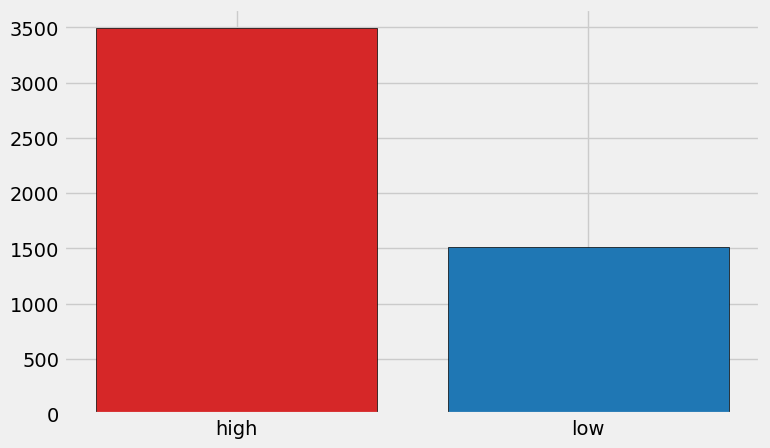

In [ ]:
#Distirbuiçao da variável alvo
#Contagem e porcentagem
counts = df['health_risk'].value_counts()
percent = (counts / counts.sum()) * 100

#cores personalizadas
colors = {'low':'#1f77b4', 'medium':'#ff7f0e', 'high':'#d62728'}

plt.figure(figsize=(8, 5))

#grafico de barras com cores personalizadas
barras = plt.bar(counts.index, counts.values, color=[colors[x] for x in counts.index],edgecolor='black')



#inserção de outros elementos

